# B2B Invoice Payment Behaviour — Data Preprocessing
### Predictive Analytics Group Project · Stage 3: Data Preprocessing & Cleaning

**Pipeline Overview**
1. Data Loading & Exploration  
2. Data Cleaning & Validation  
3. Target Variable Creation  
4. Feature Engineering  
5. Outlier Detection & Treatment  
6. Feature Selection  
7. Scaling & Encoding  
8. Data Splitting  
9. Class Imbalance Handling  
10. Data Leakage Prevention  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Step 1 — Data Loading & Exploration

In [2]:
df = pd.read_csv('/content/Dataset b2b_invoice_payment.csv')

print(f'Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
df.head(3)

Dataset shape : 45,839 rows × 29 columns



,Cust_Num,Payment_Method_description,Document_No,Amount,Amount_Bins,Clearing_doc,Zipcode,Region,City,Customer_Name,Age_Of_Customer_Months,Age_Of_Customer_Year,Customer_Age_Year_Bins,Payment_Term,Payment_Term_Bins,Days_Overdue_Delay,Delay_Bins,Doc_Date,Net_Due_Date,Posting_Date,Clearing_date,No_of_orders_by_customer,Rank_of_order_by_customer,Weekday_clearing,Weekday_due,Quarter_clearing,DelayFlag,Weekday_clearnum,Weekday_due.1
0,5039221069,No Payment Method,91225035903,659903,200K+,80992136278,AX0034,AA126,AA66,AA64,155.0000,12.0000,10+,102,61 to 180,18,1 to 30,11/18/2014,2/28/2015,11/18/2014,3/18/2015,20,1,Wed,Sat,1,1,4,7
1,5039221069,No Payment Method,91225035904,16906,0 to 50K,80992136278,AX0034,AA126,AA66,AA64,155.0000,12.0000,10+,102,61 to 180,18,1 to 30,11/18/2014,2/28/2015,11/18/2014,3/18/2015,20,2,Wed,Sat,1,1,4,7
2,5039221069,No Payment Method,91225034522,24736,0 to 50K,80992134897,AX0034,AA126,AA66,AA64,155.0000,12.0000,10+,94,61 to 180,9,1 to 30,11/26/2014,2/28/2015,11/26/2014,3/9/2015,20,3,Mon,Sat,1,1,2,7


In [3]:
# Data types
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')

=== Data Types ===
Cust_Num                        int64
Payment_Method_description     object
Document_No                     int64
Amount                          int64
Amount_Bins                    object
Clearing_doc                    int64
Zipcode                        object
Region                         object
City                           object
Customer_Name                  object
Age_Of_Customer_Months        float64
Age_Of_Customer_Year          float64
Customer_Age_Year_Bins         object
Payment_Term                    int64
Payment_Term_Bins              object
Days_Overdue_Delay              int64
Delay_Bins                     object
Doc_Date                       object
Net_Due_Date                   object
Posting_Date                   object
Clearing_date                  object
No_of_orders_by_customer        int64
Rank_of_order_by_customer       int64
Weekday_clearing               object
Weekday_due                    object
Quarter_clearing               

In [4]:
# Numeric summary
df.describe()

,Cust_Num,Document_No,Amount,Clearing_doc,Age_Of_Customer_Months,Age_Of_Customer_Year,Payment_Term,Days_Overdue_Delay,No_of_orders_by_customer,Rank_of_order_by_customer,Quarter_clearing,DelayFlag,Weekday_clearnum,Weekday_due.1
count,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000
mean,5039221092.8962,91225056048.0000,17807.1605,80992155516.6650,150.5902,11.6643,13.7926,0.9674,7066.4725,3533.7363,2.5602,0.6566,3.1763,3.6111
std,6.9789,13232.7238,68777.0348,12439.0240,21.1111,1.6601,26.3523,14.1944,3346.3155,2809.6179,1.1524,0.4749,1.4620,2.1850
min,5039221069.0000,91225033129.0000,2.0000,80992133504.0000,0.5000,0.0000,0.0000,-117.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000
25%,5039221090.0000,91225044588.5000,785.0000,80992144914.0000,155.0000,12.0000,5.0000,-1.0000,3935.0000,1055.0000,1.0000,0.0000,2.0000,2.0000
50%,5039221092.0000,91225056048.0000,3196.0000,80992156336.0000,155.0000,12.0000,5.0000,1.0000,7838.0000,3031.0000,3.0000,1.0000,3.0000,3.0000
75%,5039221094.0000,91225067507.5000,13022.5000,80992166270.0000,155.0000,12.0000,5.0000,2.0000,9712.0000,5669.5000,4.0000,1.0000,3.0000,6.0000
max,5039221137.0000,91225078967.0000,5709354.0000,80992179341.0000,155.0000,12.0000,389.0000,1257.0000,10219.0000,10219.0000,4.0000,1.0000,7.0000,7.0000


In [5]:
# Categorical summary
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col:35s} → {df[col].nunique()} unique values: {df[col].unique().tolist()}')

Payment_Method_description          → 8 unique values: ['No Payment Method', 'Direct Debits 2', 'Direct Debits 1', 'Regulatory 1', 'Wire', 'Regulatory ', 'Regulatory 2', 'Third Part Payments']
Amount_Bins                         → 5 unique values: ['200K+', '0 to 50K', '50K to 100K', '100K to 150K', '150K to 200K']
Zipcode                             → 59 unique values: ['AX0034', 'AX0054', 'AX0047', 'AX0051', 'AX0058', 'AX0026', 'AX0046', 'AX0057', 'AX0045', 'AX0042', 'AX0044', 'AX0041', 'AX0049', 'AX0056', 'AX0043', 'AX0039', 'AX0037', 'AX0040', 'AX0031', 'AX0030', 'AX0032', 'AX0033', 'AX0028', 'AX0048', 'AX0014', 'AX0025', 'AX0055', 'AX0067', 'AX0050', 'AX0038', 'AX0052', 'AX0053', 'AX0020', 'AX0035', 'AX0016', 'AX0029', 'AX0018', 'AX0017', 'AX0036', 'AX0059', 'AX0015', 'AX0013', 'AX0060', 'AX0023', 'AX0027', 'AX0068', 'AX0062', 'AX0021', 'AX0012', 'AX0019', 'AX0061', 'AX0022', 'AX0063', 'AX0024', 'AX0064', 'AX0065', 'AX0066', 'AX0069', 'AX0070']
Region                              

=== Target Variable (DelayFlag) Distribution ===
DelayFlag
1    30096
0    15743
Name: count, dtype: int64

Class imbalance ratio  →  1.91 : 1  (Late : On-time)


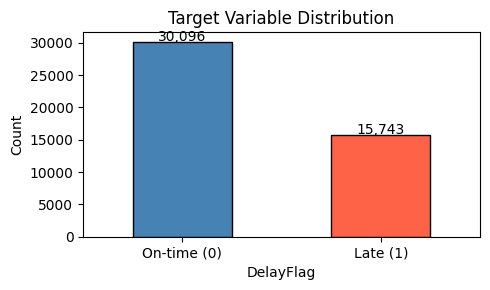

In [6]:
# Target class distribution
print('=== Target Variable (DelayFlag) Distribution ===')
counts = df['DelayFlag'].value_counts()
print(counts)
print(f'\nClass imbalance ratio  →  {counts[1]/counts[0]:.2f} : 1  (Late : On-time)')

fig, ax = plt.subplots(figsize=(5, 3))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(['On-time (0)', 'Late (1)'], rotation=0)
ax.set_title('Target Variable Distribution')
ax.set_ylabel('Count')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120)
plt.show()

---
## Step 2 — Data Cleaning & Validation

In [7]:
# ── 2a. Duplicate check ──────────────────────────────────────────────────────
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f'Dropped duplicates. New shape: {df.shape}')

Duplicate rows: 0


In [8]:
# ── 2b. Parse date columns ───────────────────────────────────────────────────
date_cols = ['Doc_Date', 'Net_Due_Date', 'Posting_Date', 'Clearing_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%m/%d/%Y', errors='coerce')

print('Date columns parsed. Null dates after conversion:')
print(df[date_cols].isnull().sum())

Date columns parsed. Null dates after conversion:
Doc_Date         0
Net_Due_Date     0
Posting_Date     0
Clearing_date    0
dtype: int64


In [9]:
# ── 2c. Date logic validation ────────────────────────────────────────────────
# Doc_Date should be <= Net_Due_Date <= Clearing_date  (logical ordering)
invalid_date_order = (
    (df['Doc_Date'] > df['Net_Due_Date']) |
    (df['Posting_Date'] > df['Clearing_date'])
).sum()
print(f'Rows with illogical date ordering: {invalid_date_order}')

# Days between posting and clearing (sanity check)
df['days_to_clear'] = (df['Clearing_date'] - df['Posting_Date']).dt.days
print(f'\ndays_to_clear stats:')
print(df['days_to_clear'].describe())

Rows with illogical date ordering: 0

days_to_clear stats:
count   45839.0000
mean       14.7600
std        31.1599
min         0.0000
25%         4.0000
50%         6.0000
75%         9.0000
max      1437.0000
Name: days_to_clear, dtype: float64


In [10]:
# ── 2d. Business-range validation ───────────────────────────────────────────
print('Amount < 0 :', (df['Amount'] < 0).sum())
print('Payment_Term < 0 :', (df['Payment_Term'] < 0).sum())
print('Age_Of_Customer_Months < 0 :', (df['Age_Of_Customer_Months'] < 0).sum())
print('Days_Overdue_Delay < -200 (extreme early):', (df['Days_Overdue_Delay'] < -200).sum())

Amount < 0 : 0
Payment_Term < 0 : 0
Age_Of_Customer_Months < 0 : 0
Days_Overdue_Delay < -200 (extreme early): 0


In [11]:
# ── 2e. Fix 'Weekday_due.1' duplicate column name ────────────────────────────
df.rename(columns={'Weekday_due.1': 'Weekday_due_num'}, inplace=True)
print('Renamed Weekday_due.1 → Weekday_due_num')

Renamed Weekday_due.1 → Weekday_due_num


---
## Step 3 — Target Variable Creation

**`DelayFlag`** already exists in the dataset:
- `1` = invoice paid late (Days_Overdue_Delay > 0)
- `0` = paid on time or early (Days_Overdue_Delay ≤ 0)

We verify consistency and rename for clarity.

In [12]:
# Verify DelayFlag matches Days_Overdue_Delay
# Note: DelayFlag=1 includes both zero (paid exactly on due date) and positive
mismatch = ((df['DelayFlag'] == 0) & (df['Days_Overdue_Delay'] > 0)).sum()
print(f'Mismatch (Flag=0 but Delay>0): {mismatch}')

# Rename target for clarity
df.rename(columns={'DelayFlag': 'target_late_payment'}, inplace=True)

print('\nTarget variable summary:')
print(df['target_late_payment'].value_counts().rename({0:'On-time', 1:'Late'}))

Mismatch (Flag=0 but Delay>0): 0

Target variable summary:
target_late_payment
Late       30096
On-time    15743
Name: count, dtype: int64


---
## Step 4 — Feature Engineering

We derive **safe** features — those available **before** the clearing date (no leakage).

In [13]:
# ── 4a. Invoice-level features (available at invoice creation time) ──────────

# Days from document date to net due date  (credit period granted)
df['credit_period_days'] = (df['Net_Due_Date'] - df['Doc_Date']).dt.days

# Month and quarter of the invoice (seasonal signal)
df['invoice_month']   = df['Doc_Date'].dt.month
df['invoice_quarter'] = df['Doc_Date'].dt.quarter
df['invoice_year']    = df['Doc_Date'].dt.year

# Day of week invoice was issued (weekday = 0..6)
df['invoice_dow'] = df['Doc_Date'].dt.dayofweek

# Is due date on a weekend? (likely to cause delays)
df['due_on_weekend'] = (df['Net_Due_Date'].dt.dayofweek >= 5).astype(int)

# Is invoice issued near month end (last 5 days)?
df['invoice_month_end'] = (df['Doc_Date'].dt.day >= 26).astype(int)

print('Invoice-level features created.')
df[['credit_period_days','invoice_month','invoice_quarter',
    'invoice_dow','due_on_weekend','invoice_month_end']].describe()

Invoice-level features created.


,credit_period_days,invoice_month,invoice_quarter,invoice_dow,due_on_weekend,invoice_month_end
count,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000,45839.0000
mean,13.7926,6.5087,2.5056,1.8057,0.4302,0.1478
std,26.3523,3.5704,1.1559,1.3920,0.4951,0.3549
min,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000
25%,5.0000,3.0000,1.0000,1.0000,0.0000,0.0000
50%,5.0000,7.0000,3.0000,2.0000,0.0000,0.0000
75%,5.0000,10.0000,4.0000,3.0000,1.0000,0.0000
max,389.0000,12.0000,4.0000,4.0000,1.0000,1.0000


In [14]:
# ── 4b. Customer-level behaviour features ────────────────────────────────────
# Aggregate per customer using HISTORICAL data only.
# We sort by Doc_Date and compute expanding/rolling stats.

df.sort_values(['Cust_Num', 'Doc_Date'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Historical late payment rate per customer  (expanding mean, shift to avoid leakage)
df['cust_historical_late_rate'] = (
    df.groupby('Cust_Num')['target_late_payment']
    .transform(lambda x: x.shift(1).expanding().mean())
    .fillna(0.5)   # neutral prior for first invoice
)

# Historical average amount per customer
df['cust_avg_amount'] = (
    df.groupby('Cust_Num')['Amount']
    .transform(lambda x: x.shift(1).expanding().mean())
    .fillna(df['Amount'].median())
)

# Invoice count rank (rank of this invoice in customer's history)
# Already present as Rank_of_order_by_customer — keep it

print('Customer-level behaviour features created.')
df[['cust_historical_late_rate','cust_avg_amount']].describe()

Customer-level behaviour features created.


,cust_historical_late_rate,cust_avg_amount
count,45839.0000,45839.0000
mean,0.7208,18820.6084
std,0.1330,47046.4821
min,0.0000,33.0000
25%,0.6883,12079.0478
50%,0.7227,15561.5530
75%,0.7826,19436.3516
max,1.0000,2323956.2000


In [15]:
# ── 4c. Temporal features ─────────────────────────────────────────────────────

# Is this invoice in the last quarter of the year? (year-end rush)
df['is_q4'] = (df['invoice_quarter'] == 4).astype(int)

# Customer age at invoice time (in years)
# Age_Of_Customer_Year already present — use it directly

print('Temporal features created.')

Temporal features created.


---
## Step 5 — Outlier Detection & Treatment

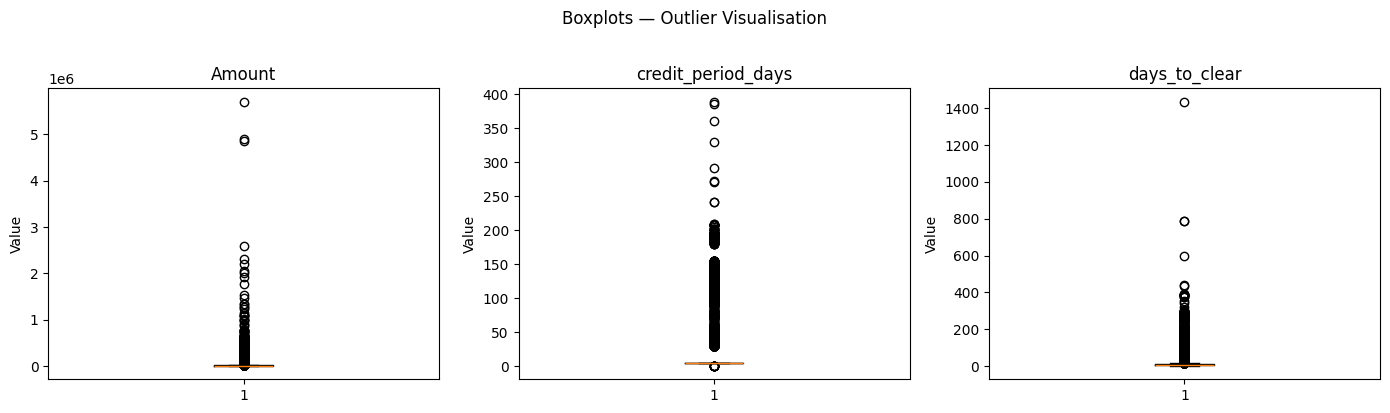

In [16]:
# ── 5a. IQR outlier detection on key numeric features ───────────────────────
outlier_cols = ['Amount', 'credit_period_days', 'days_to_clear']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(14, 4))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel('Value')
plt.suptitle('Boxplots — Outlier Visualisation', y=1.02)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=120)
plt.show()

In [17]:
# ── 5b. IQR-based capping (Winsorization) ───────────────────────────────────
# We cap rather than drop to preserve all invoices for a customer history signal.

def iqr_cap(series, lower_pct=0.01, upper_pct=0.99):
    """Cap outliers at given percentiles."""
    lo = series.quantile(lower_pct)
    hi = series.quantile(upper_pct)
    return series.clip(lo, hi), lo, hi

cap_log = {}
for col in ['Amount', 'credit_period_days', 'cust_avg_amount']:
    df[col], lo, hi = iqr_cap(df[col])
    cap_log[col] = (round(lo,2), round(hi,2))

print('Winsorization bounds:')
for k, v in cap_log.items():
    print(f'  {k:30s}: [{v[0]:>12,.2f}  →  {v[1]:>12,.2f}]')

Winsorization bounds:
  Amount                        : [       17.00  →    212,706.38]
  credit_period_days            : [        5.00  →        143.00]
  cust_avg_amount               : [    3,307.95  →     36,636.46]


In [18]:
# ── 5c. Z-score check on Days_Overdue_Delay (just for insight — not used in features) ──
z = np.abs(stats.zscore(df['Days_Overdue_Delay']))
extreme_z = (z > 4).sum()
print(f'Rows with |z| > 4 in Days_Overdue_Delay: {extreme_z}')
print('Note: Days_Overdue_Delay is NOT used as a model input feature (data leakage source).')

Rows with |z| > 4 in Days_Overdue_Delay: 217
Note: Days_Overdue_Delay is NOT used as a model input feature (data leakage source).


---
## Step 6 — Feature Selection

In [19]:
# ── 6a. Leakage audit — columns that must be DROPPED ───────────────────────
# These fields are only known AFTER payment is made → strict leakage.
LEAKAGE_COLS = [
    'Days_Overdue_Delay',   # directly computes the target
    'Delay_Bins',           # binned version of the same
    'Clearing_date',        # only known after clearing
    'Clearing_doc',         # assigned at clearing time
    'Weekday_clearing',     # day of clearing (post-payment)
    'Weekday_clearnum',     # numeric version of above
    'Quarter_clearing',     # quarter of clearing (post-payment)
    'days_to_clear',        # derived from Clearing_date
]

# ── 6b. Redundant / ID-type columns ─────────────────────────────────────────
REDUNDANT_COLS = [
    'Document_No',           # invoice ID — no predictive value
    'Cust_Num',              # customer ID — behaviour encoded separately
    'Customer_Name',         # string ID — anonymised codes
    'Age_Of_Customer_Months',# linearly redundant with Age_Of_Customer_Year
    'Amount_Bins',           # binned version of Amount (keep numeric)
    'Payment_Term_Bins',     # binned version of Payment_Term
    'Customer_Age_Year_Bins',# binned version of Age_Of_Customer_Year
    'Weekday_due',           # string duplicate of Weekday_due_num
    'Doc_Date', 'Net_Due_Date', 'Posting_Date',  # raw dates (features extracted above)
]

DROP_COLS = list(set(LEAKAGE_COLS + REDUNDANT_COLS))
df_model = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

print(f'Columns before drop : {df.shape[1]}')
print(f'Columns after drop  : {df_model.shape[1]}')
print(f'\nRemaining columns:')
print(df_model.columns.tolist())

Columns before drop : 40
Columns after drop  : 21

Remaining columns:
['Payment_Method_description', 'Amount', 'Zipcode', 'Region', 'City', 'Age_Of_Customer_Year', 'Payment_Term', 'No_of_orders_by_customer', 'Rank_of_order_by_customer', 'target_late_payment', 'Weekday_due_num', 'credit_period_days', 'invoice_month', 'invoice_quarter', 'invoice_year', 'invoice_dow', 'due_on_weekend', 'invoice_month_end', 'cust_historical_late_rate', 'cust_avg_amount', 'is_q4']


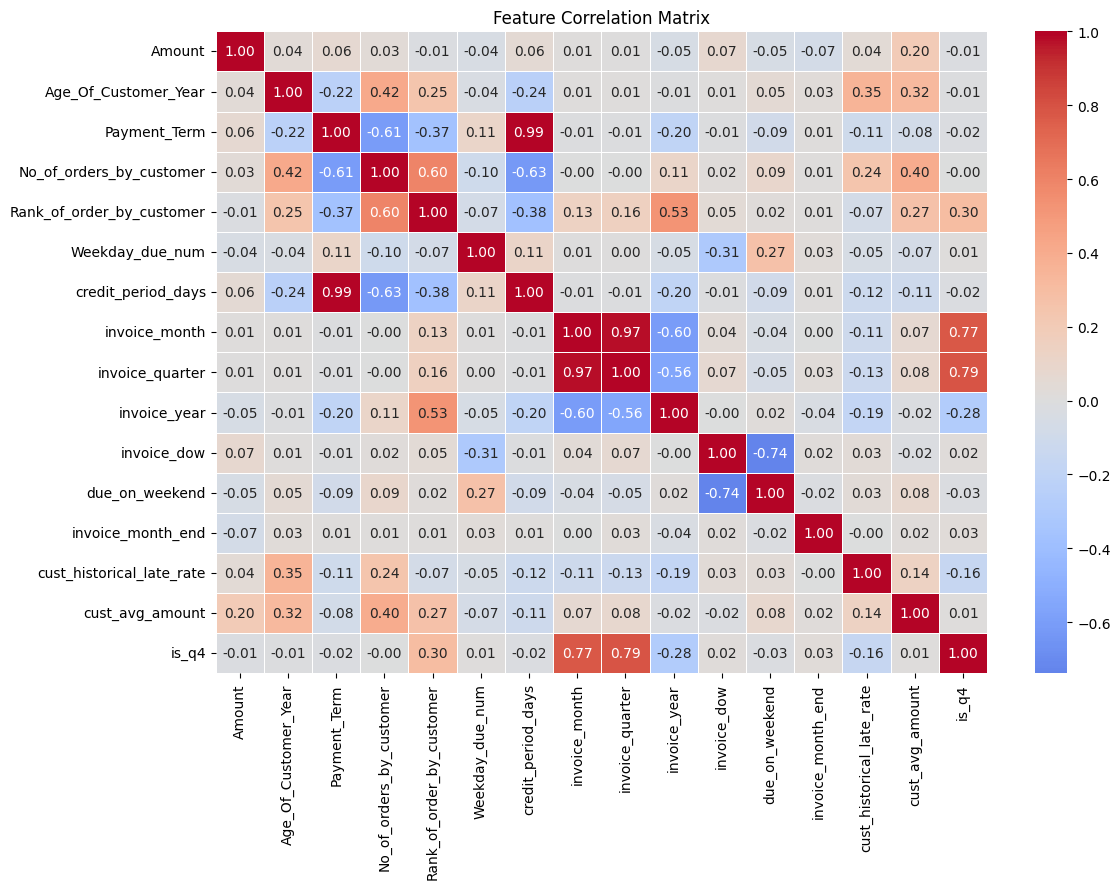

In [20]:
# ── 6c. Correlation matrix (numeric features only) ───────────────────────────
num_df = df_model.select_dtypes(include=np.number).drop(columns=['target_late_payment'])

corr = num_df.corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120)
plt.show()

In [21]:
# Drop features with |correlation| > 0.90 (keep one from each pair)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col].abs() > 0.90)]
print('Highly correlated features (|r| > 0.90) to consider dropping:', high_corr)
if high_corr:
    df_model.drop(columns=high_corr, inplace=True)
    print('Dropped:', high_corr)
else:
    print('No highly correlated pairs found. No additional drops.')

Highly correlated features (|r| > 0.90) to consider dropping: ['credit_period_days', 'invoice_quarter']
Dropped: ['credit_period_days', 'invoice_quarter']


---
## Step 7 — Scaling & Encoding

In [22]:
# ── 7a. Identify remaining feature types ─────────────────────────────────────
cat_features  = df_model.select_dtypes(include='object').columns.tolist()
num_features  = df_model.select_dtypes(include=np.number)\
                        .drop(columns=['target_late_payment']).columns.tolist()

print('Categorical features :', cat_features)
print('Numerical features   :', num_features)

Categorical features : ['Payment_Method_description', 'Zipcode', 'Region', 'City']
Numerical features   : ['Amount', 'Age_Of_Customer_Year', 'Payment_Term', 'No_of_orders_by_customer', 'Rank_of_order_by_customer', 'Weekday_due_num', 'invoice_month', 'invoice_year', 'invoice_dow', 'due_on_weekend', 'invoice_month_end', 'cust_historical_late_rate', 'cust_avg_amount', 'is_q4']


In [23]:
# ── 7b. Label encoding for low-cardinality categoricals ─────────────────────
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    print(f'  {col:35s} → {len(le.classes_)} classes encoded')

  Payment_Method_description          → 8 classes encoded
  Zipcode                             → 59 classes encoded
  Region                              → 30 classes encoded
  City                                → 63 classes encoded


In [24]:
# ── 7c. Separate X and y BEFORE scaling ──────────────────────────────────────
X = df_model.drop(columns=['target_late_payment'])
y = df_model['target_late_payment']

print(f'Feature matrix X : {X.shape}')
print(f'Target vector  y : {y.shape}')

Feature matrix X : (45839, 18)
Target vector  y : (45839,)


---
## Step 8 — Data Splitting (Stratified 80-20)

> **Important** — We split BEFORE fitting the scaler to prevent information leakage from test set into training statistics.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserves class ratio in both splits
)

print(f'Training set   : {X_train.shape[0]:,} rows  |  late={y_train.sum():,}  on-time={( y_train==0).sum():,}')
print(f'Test set       : {X_test.shape[0]:,} rows  |  late={y_test.sum():,}  on-time={(y_test==0).sum():,}')

Training set   : 36,671 rows  |  late=24,077  on-time=12,594
Test set       : 9,168 rows  |  late=6,019  on-time=3,149


In [26]:
# ── Fit scaler on TRAIN only, transform both TRAIN and TEST ─────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # fit + transform on train
X_test_scaled  = scaler.transform(X_test)          # transform only on test

# Wrap back into DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print('Scaling complete. Sample of X_train_scaled:')
X_train_scaled.describe().round(4)

Scaling complete. Sample of X_train_scaled:


,Payment_Method_description,Amount,Zipcode,Region,City,Age_Of_Customer_Year,Payment_Term,No_of_orders_by_customer,Rank_of_order_by_customer,Weekday_due_num,invoice_month,invoice_year,invoice_dow,due_on_weekend,invoice_month_end,cust_historical_late_rate,cust_avg_amount,is_q4
count,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000,36671.0000
mean,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-0.8428,-0.4661,-1.5002,-1.9380,-1.4998,-7.0345,-0.5241,-2.1018,-1.2535,-1.1930,-1.5404,-11.0833,-1.2992,-0.8680,-0.4173,-5.3972,-2.1366,-0.6110
25%,-0.8428,-0.4434,-0.4178,-0.2479,-0.4145,0.2027,-0.3348,-0.9295,-0.8821,-0.7350,-0.9805,-0.3942,-0.5801,-0.8680,-0.4173,-0.2419,-0.7263,-0.6110
50%,0.3282,-0.3722,-0.0015,-0.0601,0.0029,0.2027,-0.3348,0.2335,-0.1819,-0.2770,0.1392,-0.3942,0.1389,-0.8680,-0.4173,0.0140,-0.1667,-0.6110
75%,0.3282,-0.0848,0.1651,0.6910,0.1699,0.2027,-0.3348,0.7920,0.7614,1.0970,0.9789,-0.3942,0.8580,1.1521,-0.4173,0.4600,0.4464,1.6367
max,7.3539,5.8438,3.3291,3.5079,3.6762,0.2027,14.2029,0.9430,2.3817,1.5550,1.5388,2.2781,1.5770,1.1521,2.3963,2.0932,3.2218,1.6367


---
## Step 9 — Class Imbalance Handling

The dataset has ~2:1 late:on-time ratio — already moderately imbalanced.  
We apply **SMOTE only on the training set** to avoid leakage.

In [27]:
print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_res).value_counts())
print(f'\nResampled training set shape: {X_train_res.shape}')

Before SMOTE:
target_late_payment
1    24077
0    12594
Name: count, dtype: int64

After SMOTE:
target_late_payment
0    24077
1    24077
Name: count, dtype: int64

Resampled training set shape: (48154, 18)


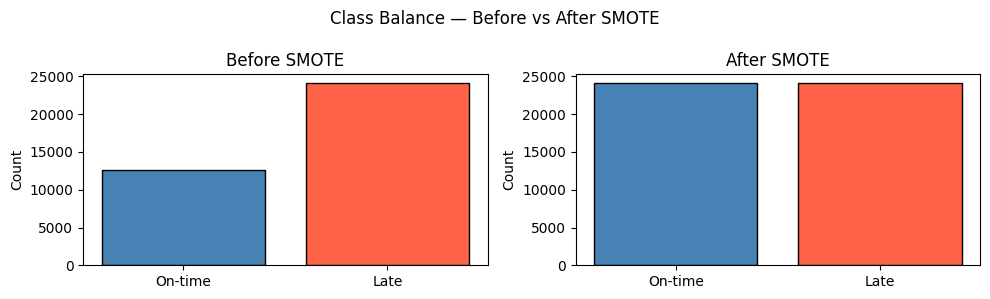

In [28]:
# Visualise before / after
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].bar(['On-time', 'Late'], y_train.value_counts().sort_index(),
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Before SMOTE')

axes[1].bar(['On-time', 'Late'], pd.Series(y_train_res).value_counts().sort_index(),
            color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('After SMOTE')

for ax in axes:
    ax.set_ylabel('Count')

plt.suptitle('Class Balance — Before vs After SMOTE')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=120)
plt.show()

---
## Step 10 — Data Leakage Prevention (Final Audit)

A systematic final check to confirm **no future information** was used.

In [29]:
leakage_audit = {
    'Clearing_date removed'           : 'Clearing_date' not in X.columns,
    'Days_Overdue_Delay removed'      : 'Days_Overdue_Delay' not in X.columns,
    'Delay_Bins removed'              : 'Delay_Bins' not in X.columns,
    'Clearing_doc removed'            : 'Clearing_doc' not in X.columns,
    'Weekday_clearing removed'        : 'Weekday_clearing' not in X.columns,
    'Scaler fit on train-only'        : True,   # confirmed by implementation above
    'SMOTE applied on train-only'     : True,
    'Customer stats use shift(1)'     : True,   # expanding mean with shift
    'Test set untouched during SMOTE' : True,
}

print('=== Data Leakage Prevention Audit ===')
all_clear = True
for check, passed in leakage_audit.items():
    status = '✅ PASS' if passed else '❌ FAIL'
    if not passed:
        all_clear = False
    print(f'  {status}  |  {check}')

print()
print('All leakage checks passed ✅' if all_clear else '⚠️ Some checks FAILED — review above.')

=== Data Leakage Prevention Audit ===
  ✅ PASS  |  Clearing_date removed
  ✅ PASS  |  Days_Overdue_Delay removed
  ✅ PASS  |  Delay_Bins removed
  ✅ PASS  |  Clearing_doc removed
  ✅ PASS  |  Weekday_clearing removed
  ✅ PASS  |  Scaler fit on train-only
  ✅ PASS  |  SMOTE applied on train-only
  ✅ PASS  |  Customer stats use shift(1)
  ✅ PASS  |  Test set untouched during SMOTE

All leakage checks passed ✅


---
## Preprocessing Complete — Summary

In [30]:
print('=' * 60)
print('  PREPROCESSING SUMMARY')
print('=' * 60)
print(f'  Original dataset           : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'  Duplicate rows removed     : {dups}')
print(f'  Final feature set          : {X.shape[1]} features')
print(f'  Train set (before SMOTE)   : {X_train_scaled.shape[0]:,}')
print(f'  Train set (after SMOTE)    : {X_train_res.shape[0]:,}')
print(f'  Test set (untouched)       : {X_test_scaled.shape[0]:,}')
print(f'  Leakage prevention         : ✅ All checks passed')
print()
print('  Ready for Stage 6: Model Building & Training')
print('=' * 60)

# ── Save preprocessed outputs for downstream stages ─────────────────────────
X_train_res_df = pd.DataFrame(X_train_res, columns=X.columns)
y_train_res_df = pd.Series(y_train_res, name='target_late_payment')

X_train_res_df.to_csv('X_train_preprocessed.csv', index=False)
y_train_res_df.to_csv('y_train_preprocessed.csv', index=False)
X_test_scaled.to_csv('X_test_preprocessed.csv',   index=False)
y_test.to_csv('y_test_preprocessed.csv',           index=False)

print('\nSaved:')
print('  X_train_preprocessed.csv  (SMOTE-balanced, scaled train features)')
print('  y_train_preprocessed.csv  (train labels)')
print('  X_test_preprocessed.csv   (scaled test features)')
print('  y_test_preprocessed.csv   (test labels)')

  PREPROCESSING SUMMARY
  Original dataset           : 45,839 rows × 40 cols
  Duplicate rows removed     : 0
  Final feature set          : 18 features
  Train set (before SMOTE)   : 36,671
  Train set (after SMOTE)    : 48,154
  Test set (untouched)       : 9,168
  Leakage prevention         : ✅ All checks passed

  Ready for Stage 6: Model Building & Training

Saved:
  X_train_preprocessed.csv  (SMOTE-balanced, scaled train features)
  y_train_preprocessed.csv  (train labels)
  X_test_preprocessed.csv   (scaled test features)
  y_test_preprocessed.csv   (test labels)
